# Financial Modelling: Baseline ARX

This notebook implements baseline ARX (AutoRegressive with eXogenous variables) models for predicting asset returns using only:
- **AR lags**: Past returns of the target asset
- **Macro-financial controls**: EUR/USD, USD/CNY exchange rates, oil prices, 10Y Treasury yield

No emotion/social indices are included - this serves as the baseline for comparison with enhanced models.

## Evaluation Metrics
- **MAE** (Mean Absolute Error): Primary metric
- **RMSE** (Root Mean Squared Error): Secondary metric
- **Cumulative Returns**: Strategy performance vs buy-and-hold

In [1]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Set display options
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 6)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Project paths
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Output directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [2]:
# Import custom modules
from modules.finance.models.arx import (
    LagSpec, 
    automl_group_arx, 
    make_group_arx_supervised,
    run_three_assets_on_returns
)
from modules.finance.evaluation.metrics import (
    compute_all_metrics,
    bootstrap_coefficient_ci,
    compare_cv_methods
)
from modules.finance.visualisation.feature_importance import (
    plot_coefficient_importance,
    plot_model_comparison_bars
)

print("Modules imported successfully")

Modules imported successfully


## Load Data

Load the financial returns dataset with controls. Target variables are:
- `r_btc`: Bitcoin daily returns
- `r_gold`: Gold daily returns  
- `r_spx`: S&P 500 daily returns

Control variables:
- `dln_eurusd`: EUR/USD log changes
- `dln_usdcny`: USD/CNY log changes
- `dln_oil`: Oil price log changes
- `dy10`: 10-year Treasury yield changes

In [3]:
# Load financial data
df = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df = df.sort_index()

# Define target and control columns
TARGET_COLS = ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
CONTROL_COLS = ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

# Forward fill controls to handle missing values
for col in CONTROL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Drop rows with missing targets
df_clean = df.dropna(subset=TARGET_COLS)

print(f"Data shape: {df_clean.shape}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"\nTarget columns: {TARGET_COLS}")
print(f"Control columns: {CONTROL_COLS}")
print(f"\nMissing values per column:")
print(df_clean[TARGET_COLS + CONTROL_COLS].isna().sum())

Data shape: (104, 44)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00

Target columns: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']
Control columns: ['dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10']

Missing values per column:
r_btc           0
r_gold          0
r_spx           0
r_spx_auto      0
r_spx_oilgas    0
r_spx_mach      0
r_spx_elec      0
r_aapl          0
dln_eurusd      0
dln_usdcny      0
dln_oil         0
dy10            0
dtype: int64


## Baseline ARX Configuration

Define the baseline model specification with:
- AR lags to optimize: range [1, 5]
- Control lags to optimize: range [0, 3]
- **No emotion indices** (all q_* set to 0)
- Cross-asset lags: 0 (univariate model)

In [4]:
# Baseline configuration - NO emotion indices
BASELINE_CONFIG = {
    # AR and control lag ranges to optimize
    'p_range': (1, 5),          # AR lags
    'q_control_range': (0, 3),  # Control lags
    
    # All emotion index families set to 0
    'q_ei_range': (0, 0),
    'q_epi_range': (0, 0),
    'q_epi_signed_range': (0, 0),
    'q_ccd_range': (0, 0),
    'q_intensity_range': (0, 0),
    'q_surprise_range': (0, 0),
    'q_split_range': (0, 0),
    
    # No cross-asset spillovers (univariate)
    'q_cross_range': (0, 0),
    
    # Optimization settings
    'n_trials': 300,
    'cv_initial': 60,
    'cv_step': 1,
    'cv_test': 1,
}

print("Baseline ARX Configuration:")
for key, value in BASELINE_CONFIG.items():
    print(f"  {key}: {value}")

Baseline ARX Configuration:
  p_range: (1, 5)
  q_control_range: (0, 3)
  q_ei_range: (0, 0)
  q_epi_range: (0, 0)
  q_epi_signed_range: (0, 0)
  q_ccd_range: (0, 0)
  q_intensity_range: (0, 0)
  q_surprise_range: (0, 0)
  q_split_range: (0, 0)
  q_cross_range: (0, 0)
  n_trials: 300
  cv_initial: 60
  cv_step: 1
  cv_test: 1


## Train Baseline Models

Train separate ARX models for each asset using Optuna optimization with rolling window cross-validation. Compare rolling vs expanding window to select the better CV method.

In [5]:
# Store results for each asset
baseline_results = {}

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"Training baseline ARX for {target}")
    print('='*60)
    
    # Prepare data - only controls, no emotion indices
    y = df_clean[target]
    controls = df_clean[CONTROL_COLS].fillna(0)
    
    # Run automl optimization
    result = automl_group_arx(
        y=y,
        social=None,  # No emotion indices
        controls=controls,
        cross=None,  # No cross-asset predictors
        p_range=BASELINE_CONFIG['p_range'],
        q_controls_range=BASELINE_CONFIG['q_control_range'],
        q_cross_range=BASELINE_CONFIG['q_cross_range'],
        q_ei_range=BASELINE_CONFIG['q_ei_range'],
        q_epi_range=BASELINE_CONFIG['q_epi_range'],
        q_epi_signed_range=BASELINE_CONFIG['q_epi_signed_range'],
        q_ccd_range=BASELINE_CONFIG['q_ccd_range'],
        q_intensity_range=BASELINE_CONFIG['q_intensity_range'],
        q_surprise_range=BASELINE_CONFIG['q_surprise_range'],
        q_split_range=BASELINE_CONFIG['q_split_range'],
        n_trials=BASELINE_CONFIG['n_trials'],
        initial_train_size=BASELINE_CONFIG['cv_initial'],
        step_size=BASELINE_CONFIG['cv_step'],
        test_size=BASELINE_CONFIG['cv_test'],
    )
    
    # Store results
    baseline_results[target] = {
        'best_lags': result['best_lags'],
        'best_model_params': result['best_model_params'],
        'fitted_pipeline': result['fitted_pipeline'],
        'cv_mae': result['best_score_mae'],
        'cv_rmse': result['best_score_rmse'],
        'coef_sorted': result['coef_sorted'],
        'feature_names': result['feature_names'],
        'X_supervised': result['X_supervised'],
        'y_supervised': result['y_supervised'],
    }
    
    print(f"\nBest specification for {target}:")
    print(f"  AR lags (p): {result['best_lags'].ar_p}")
    print(f"  Control lags (q_controls): {result['best_lags'].q_controls}")
    print(f"  CV MAE: {result['best_score_mae']:.6f}")
    print(f"  CV RMSE: {result['best_score_rmse']:.6f}")

[I 2026-01-31 16:37:15,972] A new study created in memory with name: no-name-5a1f67e9-affc-4223-a83b-e317a75ffa06



Training baseline ARX for r_btc


Optuna Optimization: 100%|██████████| 300/300 [00:13<00:00, 22.42it/s, best_mae=0.0152]



Best specification for r_btc:
  AR lags (p): 5
  Control lags (q_controls): 0
  CV MAE: 0.015244
  CV RMSE: 0.015244

Training baseline ARX for r_gold


Optuna Optimization: 100%|██████████| 300/300 [00:11<00:00, 25.17it/s, best_mae=0.00927]


...


Best specification for r_spx_mach:
  AR lags (p): 3
  Control lags (q_controls): 1
  CV MAE: 0.010355
  CV RMSE: 0.010355

Training baseline ARX for r_spx_elec


Optuna Optimization: 100%|██████████| 300/300 [00:13<00:00, 21.63it/s, best_mae=0.0124]



Best specification for r_spx_elec:
  AR lags (p): 1
  Control lags (q_controls): 3
  CV MAE: 0.012377
  CV RMSE: 0.012377

Training baseline ARX for r_aapl


Optuna Optimization: 100%|██████████| 300/300 [00:13<00:00, 21.97it/s, best_mae=0.0166]


Best specification for r_aapl:
  AR lags (p): 5
  Control lags (q_controls): 3
  CV MAE: 0.016622
  CV RMSE: 0.016622


In [6]:
# Summary of best specifications
print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)

summary_data = []
for target, results in baseline_results.items():
    lags = results['best_lags']
    summary_data.append({
        'Asset': target,
        'AR Lags (p)': lags.ar_p,
        'Control Lags (q_controls)': lags.q_controls,
        'CV MAE': results['cv_mae'],
        'CV RMSE': results['cv_rmse'],
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.format({
    'CV MAE': '{:.6f}',
    'CV RMSE': '{:.6f}'
}))


BASELINE MODEL SUMMARY


,Asset,AR Lags (p),Control Lags (q_controls),CV MAE,CV RMSE
0,r_btc,5,0,0.015244,0.015244
1,r_gold,2,1,0.009274,0.009274
2,r_spx,1,3,0.009901,0.009901
3,r_spx_auto,2,3,0.023059,0.023059
4,r_spx_oilgas,1,3,0.010043,0.010043
5,r_spx_mach,3,1,0.010355,0.010355
6,r_spx_elec,1,3,0.012377,0.012377
7,r_aapl,5,3,0.016622,0.016622


## Out-of-Sample Evaluation

Generate out-of-sample predictions using rolling window forecasts and compute evaluation metrics.

In [7]:
# Generate OOS predictions for each asset
oos_predictions = {}
oos_metrics = {}

for target in TARGET_COLS:
    print(f"\nGenerating OOS predictions for {target}...")
    
    lags = baseline_results[target]['best_lags']
    y = df_clean[target]
    controls = df_clean[CONTROL_COLS].fillna(0)
    
    # Build design matrix with optimal lags
    X_design, y_design = make_group_arx_supervised(
        y=y,
        social=None,
        controls=controls,
        cross=None,
        lags=lags
    )
    
    # Rolling window OOS predictions
    y_true_list = []
    y_pred_list = []
    dates_list = []
    
    # Use same CV settings as training
    initial_train = BASELINE_CONFIG['cv_initial']
    step_size = BASELINE_CONFIG['cv_step']
    test_size = BASELINE_CONFIG['cv_test']
    
    n_samples = len(y_design)
    max_lag = max(lags.ar_p, lags.q_controls)
    
    # Get the pipeline and model parameters
    pipeline = baseline_results[target]['fitted_pipeline']
    model_params = baseline_results[target]['best_model_params']
    
    for train_end in range(initial_train, n_samples - test_size + 1, step_size):
        test_start = train_end
        test_end = test_start + test_size
        
        # Train on window
        X_train = X_design.iloc[:train_end].values
        y_train = y_design.iloc[:train_end].values
        
        # Test on next step
        X_test = X_design.iloc[test_start:test_end].values
        y_test = y_design.iloc[test_start:test_end].values
        
        # Clone and fit a new pipeline for each fold
        from sklearn.base import clone
        model = clone(pipeline)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        y_true_list.extend(y_test)
        y_pred_list.extend(y_pred)
        dates_list.extend(X_design.index[test_start:test_end].tolist())
    
    # Store predictions
    oos_predictions[target] = pd.DataFrame({
        'date': dates_list,
        'y_true': y_true_list,
        'y_pred': y_pred_list
    }).set_index('date')
    
    # Compute metrics
    oos_metrics[target] = compute_all_metrics(
        np.array(y_true_list), 
        np.array(y_pred_list)
    )
    
    print(f"  OOS samples: {len(y_true_list)}")
    print(f"  OOS MAE: {oos_metrics[target]['mae']:.6f}")
    print(f"  OOS RMSE: {oos_metrics[target]['rmse']:.6f}")


Generating OOS predictions for r_btc...
  OOS samples: 38
  OOS MAE: 0.015244
  OOS RMSE: 0.019570

Generating OOS predictions for r_gold...
  OOS samples: 41
  OOS MAE: 0.009274
  OOS RMSE: 0.011982

Generating OOS predictions for r_spx...
  OOS samples: 40
  OOS MAE: 0.009901
  OOS RMSE: 0.015690

Generating OOS predictions for r_spx_auto...
  OOS samples: 40
  OOS MAE: 0.023059
  OOS RMSE: 0.033674

Generating OOS predictions for r_spx_oilgas...
  OOS samples: 40
  OOS MAE: 0.010043
  OOS RMSE: 0.014183

Generating OOS predictions for r_spx_mach...
  OOS samples: 40
  OOS MAE: 0.010355
  OOS RMSE: 0.015926

Generating OOS predictions for r_spx_elec...
  OOS samples: 40
  OOS MAE: 0.012377
  OOS RMSE: 0.018099

Generating OOS predictions for r_aapl...
  OOS samples: 38
  OOS MAE: 0.016622
  OOS RMSE: 0.025526


In [8]:
# Display OOS metrics summary
print("\n" + "="*60)
print("OUT-OF-SAMPLE METRICS SUMMARY")
print("="*60)

metrics_data = []
for target, metrics in oos_metrics.items():
    metrics_data.append({
        'Asset': target,
        'MAE': metrics['mae'],
        'RMSE': metrics['rmse'],
        'MAPE (%)': metrics['mape'],
        'R²': metrics['r2']
    })

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.style.format({
    'MAE': '{:.6f}',
    'RMSE': '{:.6f}',
    'MAPE (%)': '{:.2f}',
    'R²': '{:.4f}',
    'Dir. Accuracy (%)': '{:.1f}'
}))


OUT-OF-SAMPLE METRICS SUMMARY


,Asset,MAE,RMSE,MAPE (%),R²
0,r_btc,0.015244,0.019570,353.36,-0.0661
1,r_gold,0.009274,0.011982,84.55,-0.2531
2,r_spx,0.009901,0.015690,646.27,-0.0002
3,r_spx_auto,0.023059,0.033674,272.85,-0.0186
4,r_spx_oilgas,0.010043,0.014183,269.96,0.0994
5,r_spx_mach,0.010355,0.015926,204.84,-0.0207
6,r_spx_elec,0.012377,0.018099,331.77,0.0585
7,r_aapl,0.016622,0.025526,298.82,-0.0176


## Cumulative Returns Analysis

Compute and visualize cumulative returns from trading strategies based on model predictions.

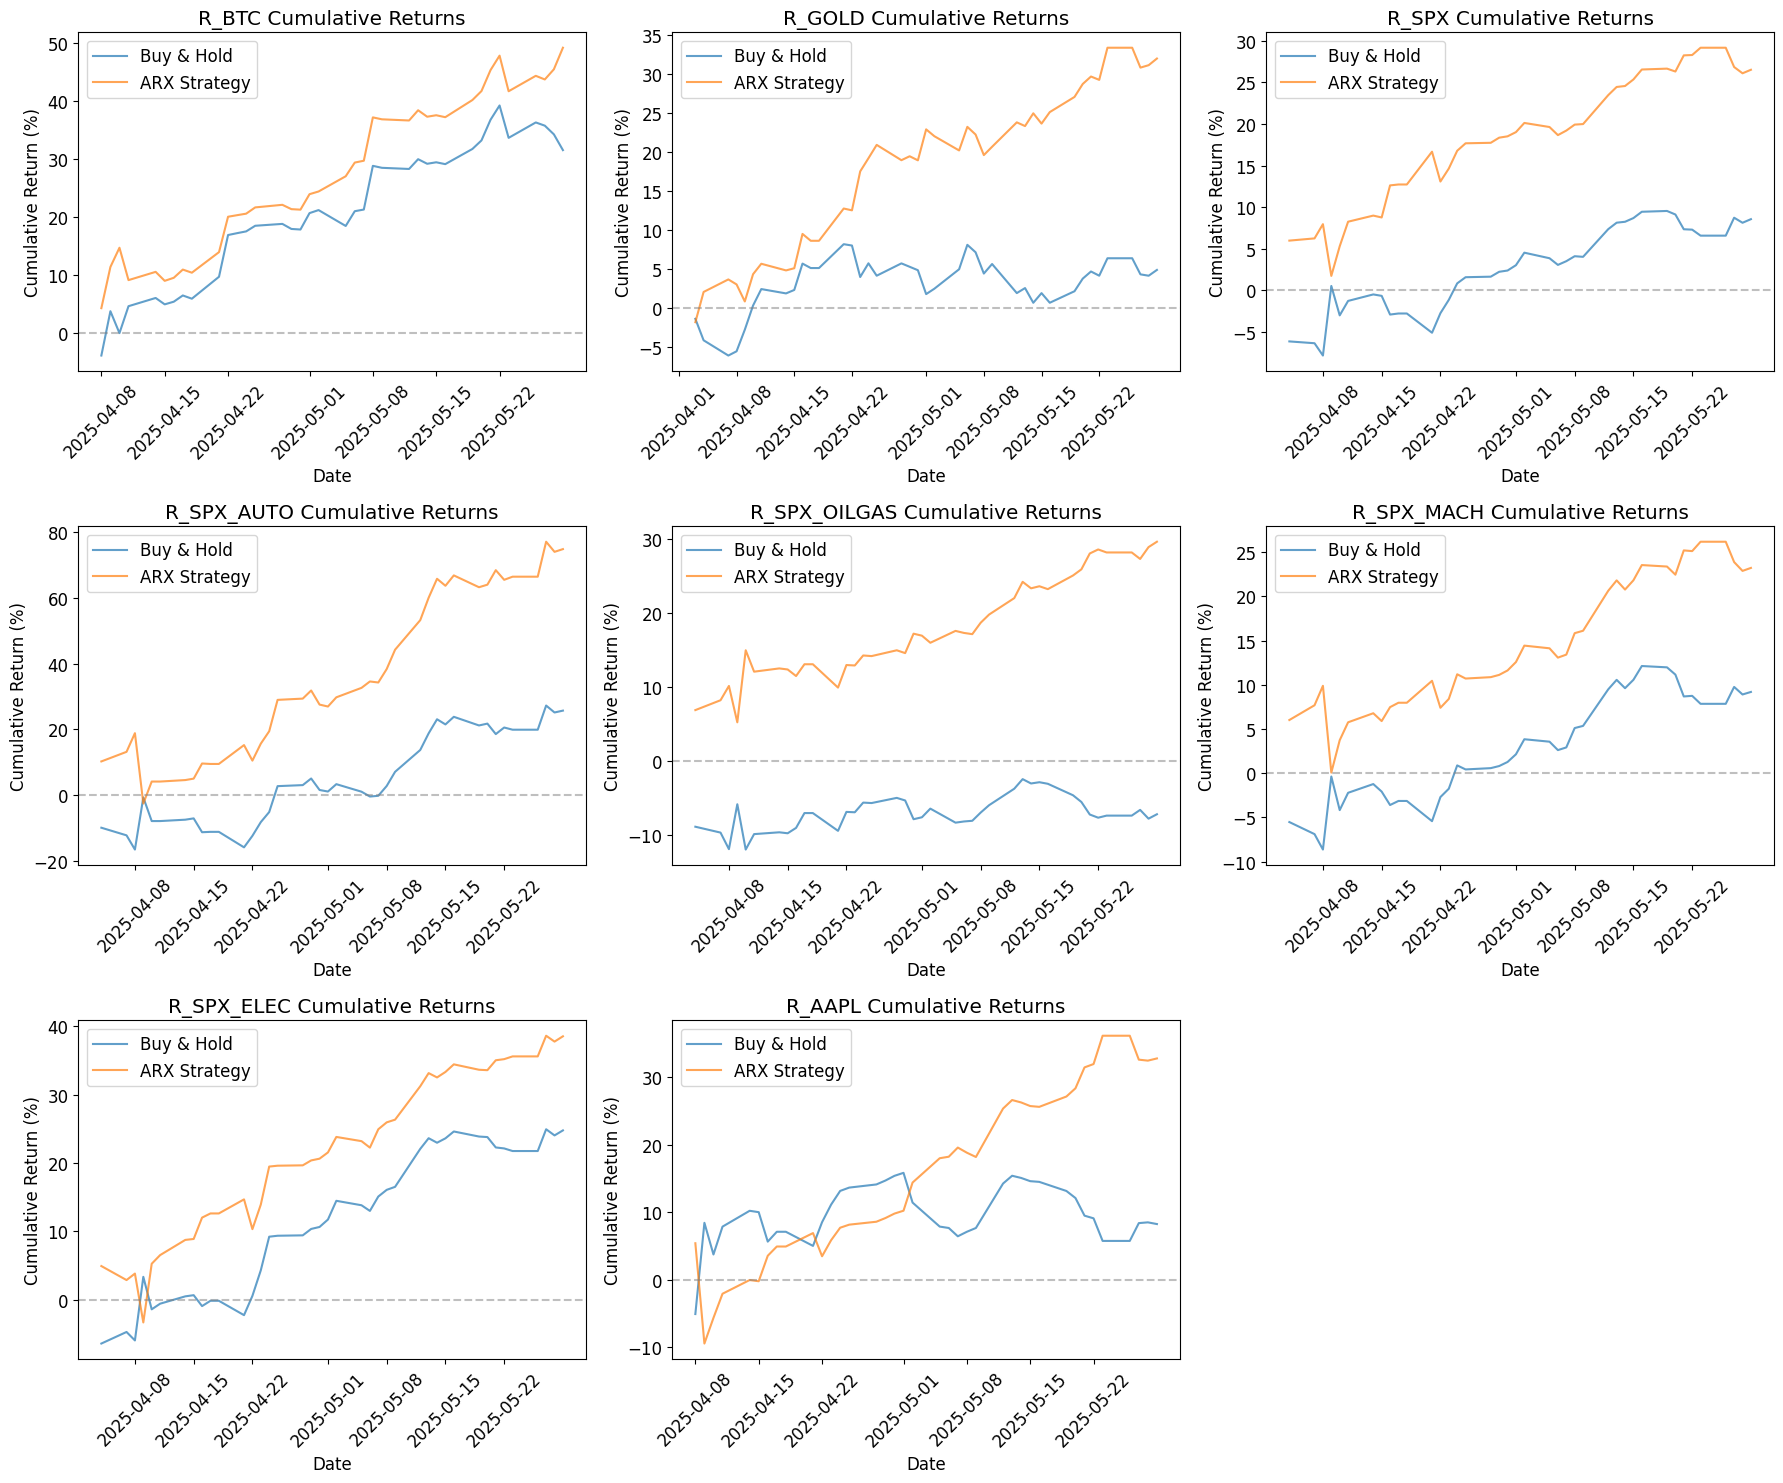


Cumulative Returns Summary:
  r_btc:
    Buy & Hold: 31.57%
    Strategy:   49.21%
  r_gold:
    Buy & Hold: 4.88%
    Strategy:   31.93%
  r_spx:
    Buy & Hold: 8.55%
    Strategy:   26.53%
  r_spx_auto:
    Buy & Hold: 25.67%
    Strategy:   74.82%
  r_spx_oilgas:
    Buy & Hold: -7.15%
    Strategy:   29.64%
  r_spx_mach:
    Buy & Hold: 9.19%
    Strategy:   23.21%
  r_spx_elec:
    Buy & Hold: 24.76%
    Strategy:   38.51%
  r_aapl:
    Buy & Hold: 8.24%
    Strategy:   32.80%

Trading Metrics Summary:

R_BTC:
  Sharpe Ratio:     7.555
  Sortino Ratio:    10.288
  Calmar Ratio:     54.956
  Max Drawdown:     -4.97%
  Win Rate:         71.1%
  Profit Factor:    4.06

R_GOLD:
  Sharpe Ratio:     5.972
  Sortino Ratio:    16.490
  Calmar Ratio:     59.655
  Max Drawdown:     -2.93%
  Win Rate:         56.1%
  Profit Factor:    2.65

R_SPX:
  Sharpe Ratio:     5.132
  Sortino Ratio:    4.969
  Calmar Ratio:     26.527
  Max Drawdown:     -5.77%
  Win Rate:         75.0%
  Profit Fac

In [9]:
# Compute momentum-based trading strategy with volatility scaling
from modules.finance.evaluation.trading_metrics import (
    generate_volatility_scaled_positions,
    compute_trading_metrics
)

cumulative_returns = {}
trading_metrics_all = {}

n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    preds_df = oos_predictions[target]
    
    # Get asset name
    asset = target.replace('r_', '')
    
    # Get momentum signal (5-day primary) and convert to ±1
    momentum_col = f'momentum_5d_{asset}'
    if momentum_col not in df_clean.columns:
        print(f"Warning: {momentum_col} not found, using sign of predictions")
        momentum_signal = np.sign(preds_df['y_pred'].values)
    else:
        # Align momentum with prediction dates and convert to directional signal
        momentum_values = df_clean.loc[preds_df.index, momentum_col].values
        momentum_signal = np.sign(momentum_values)  # Convert to ±1
    
    # Get signed actual returns (MUST use signed column, not y_true which is absolute)
    signed_col = f'r_{asset}_signed'
    if signed_col in df_clean.columns:
        actual_signed_returns = df_clean.loc[preds_df.index, signed_col].values
    else:
        # Fallback: convert absolute returns to signed using momentum
        print(f"Warning: {signed_col} not found, reconstructing from absolute returns")
        actual_signed_returns = preds_df['y_true'].values * momentum_signal
    
    # Generate volatility-scaled positions
    # y_pred contains predicted volatility (absolute returns), use for inverse vol weighting
    predicted_volatility = preds_df['y_pred'].values
    positions = generate_volatility_scaled_positions(
        momentum_signals=momentum_signal,
        predicted_volatility=predicted_volatility,
        percentile_cap=95,
        percentile_floor=5
    )
    
    # Strategy returns (position * actual signed return)
    strategy_returns = positions * actual_signed_returns
    
    # Cumulative returns
    cum_buy_hold = np.cumprod(1 + actual_signed_returns) - 1
    cum_strategy = np.cumprod(1 + strategy_returns) - 1
    
    cumulative_returns[target] = {
        'dates': preds_df.index,
        'buy_hold': cum_buy_hold,
        'strategy': cum_strategy,
        'final_buy_hold': cum_buy_hold[-1],
        'final_strategy': cum_strategy[-1],
    }
    
    # Compute trading metrics
    trading_metrics = compute_trading_metrics(
        strategy_returns=strategy_returns,
        buy_hold_returns=actual_signed_returns
    )
    trading_metrics_all[target] = trading_metrics
    
    # Plot
    ax = axes[idx]
    ax.plot(preds_df.index, cum_buy_hold * 100, label='Buy & Hold', alpha=0.7)
    ax.plot(preds_df.index, cum_strategy * 100, label='ARX Strategy', alpha=0.7)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{target.upper()} Cumulative Returns')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best')
    ax.tick_params(axis='x', rotation=45)

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\nCumulative Returns Summary:")
for target, data in cumulative_returns.items():
    print(f"  {target}:")
    print(f"    Buy & Hold: {data['final_buy_hold']*100:.2f}%")
    print(f"    Strategy:   {data['final_strategy']*100:.2f}%")

print("\nTrading Metrics Summary:")
for target, metrics in trading_metrics_all.items():
    print(f"\n{target.upper()}:")
    print(f"  Sharpe Ratio:     {metrics['sharpe_ratio']:.3f}")
    print(f"  Sortino Ratio:    {metrics['sortino_ratio']:.3f}")
    print(f"  Calmar Ratio:     {metrics['calmar_ratio']:.3f}")
    print(f"  Max Drawdown:     {metrics['max_drawdown']*100:.2f}%")
    print(f"  Win Rate:         {metrics['win_rate']*100:.1f}%")
    print(f"  Profit Factor:    {metrics['profit_factor']:.2f}")

## Volatility Clustering and Overfitting Diagnostics

Analyze volatility clustering in residuals and assess model overfitting through IC metrics and coefficient stability.

VOLATILITY CLUSTERING ANALYSIS (ACF of Squared Residuals)

R_BTC:
  ACF(1):  0.0284
  ACF(5):  -0.0960
  ACF(10): 0.0498
  Ljung-Box p-value: 0.9868
  ✗ No significant volatility clustering (p >= 0.05)


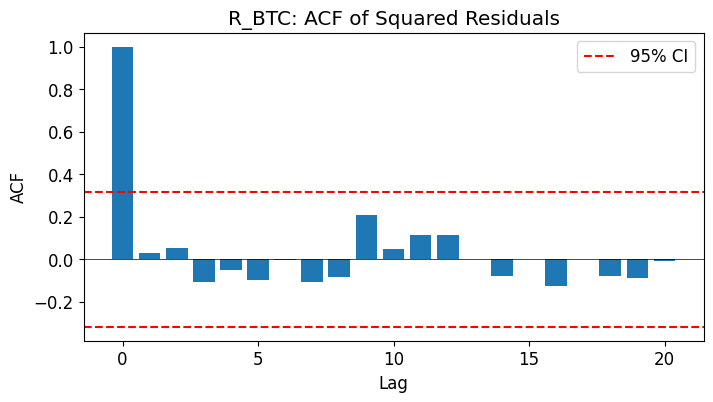


R_GOLD:
  ACF(1):  -0.1519
  ACF(5):  0.4709
  ACF(10): -0.0055
  Ljung-Box p-value: 0.2518
  ✗ No significant volatility clustering (p >= 0.05)


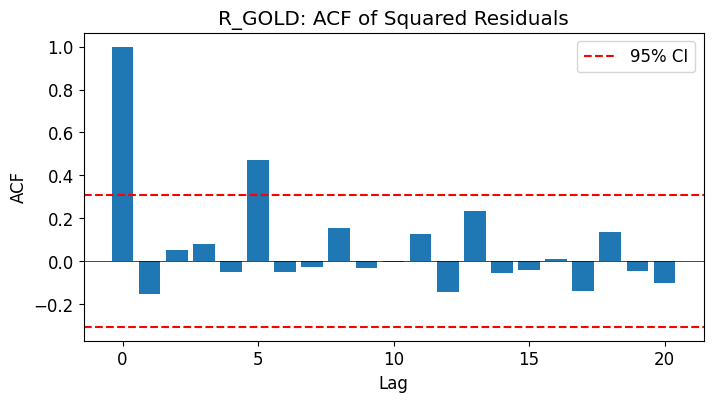


R_SPX:
  ACF(1):  -0.0127
  ACF(5):  0.0164
  ACF(10): -0.0080
  Ljung-Box p-value: 1.0000
  ✗ No significant volatility clustering (p >= 0.05)


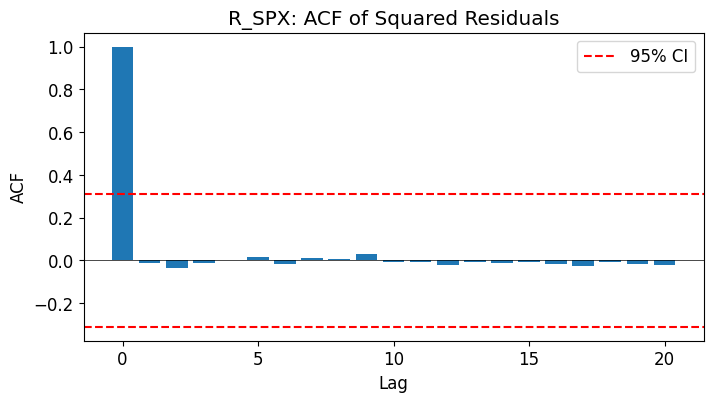


R_SPX_AUTO:
  ACF(1):  -0.0001
  ACF(5):  -0.0188
  ACF(10): -0.0153
  Ljung-Box p-value: 1.0000
  ✗ No significant volatility clustering (p >= 0.05)


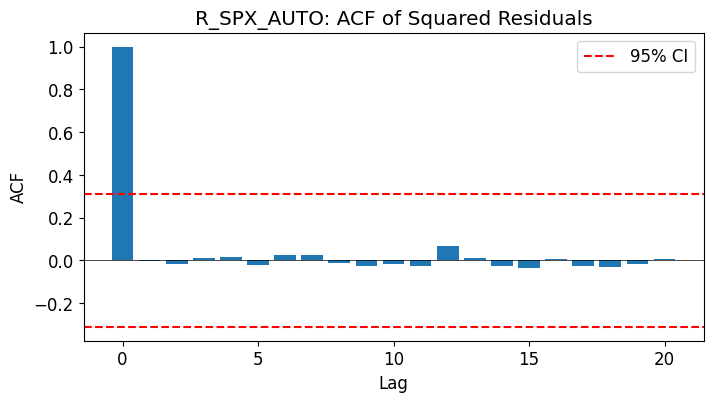


R_SPX_OILGAS:
  ACF(1):  0.5020
  ACF(5):  -0.0133
  ACF(10): -0.0086
  Ljung-Box p-value: 0.9120
  ✗ No significant volatility clustering (p >= 0.05)


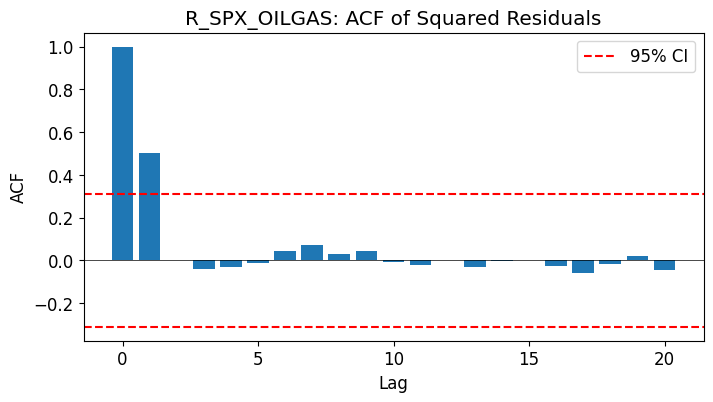


R_SPX_MACH:
  ACF(1):  0.0482
  ACF(5):  -0.0175
  ACF(10): -0.0182
  Ljung-Box p-value: 1.0000
  ✗ No significant volatility clustering (p >= 0.05)


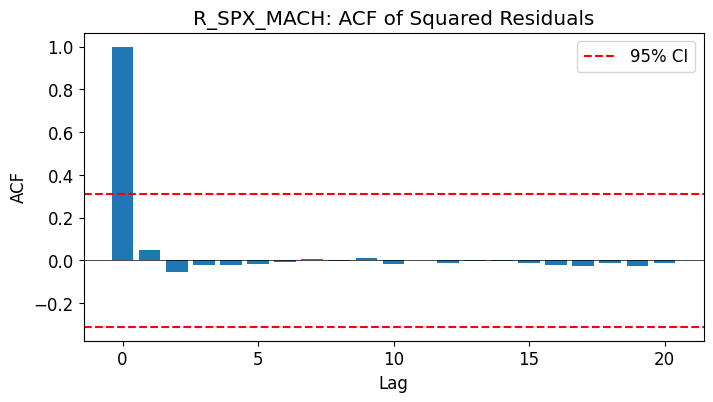


R_SPX_ELEC:
  ACF(1):  0.0048
  ACF(5):  -0.0380
  ACF(10): 0.0793
  Ljung-Box p-value: 1.0000
  ✗ No significant volatility clustering (p >= 0.05)


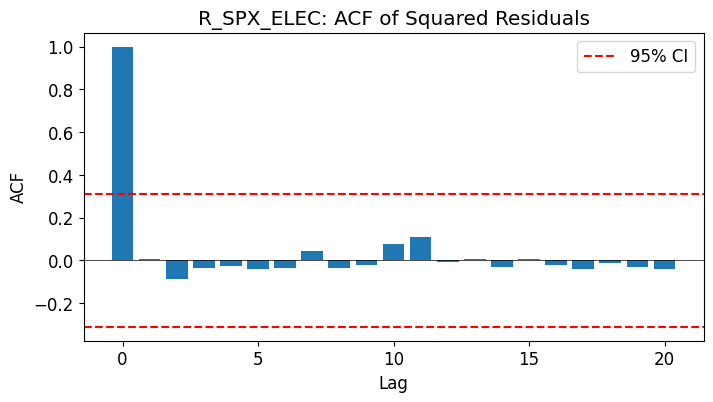


R_AAPL:
  ACF(1):  0.0200
  ACF(5):  0.0058
  ACF(10): -0.0218
  Ljung-Box p-value: 1.0000
  ✗ No significant volatility clustering (p >= 0.05)


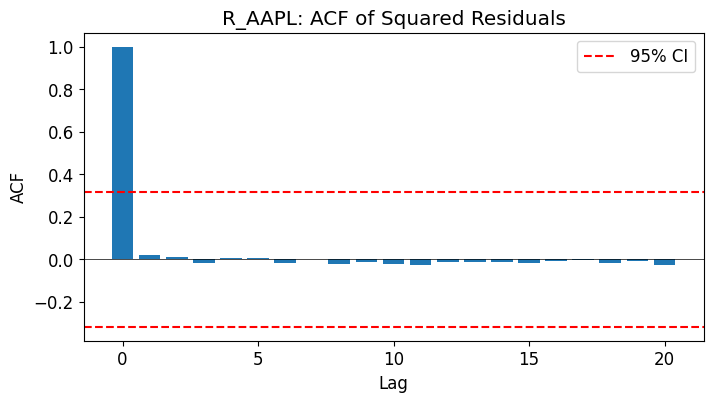


OVERFITTING DIAGNOSTICS (Information Coefficient)

R_BTC:
  Overall IC:       -0.0378
  Mean Rolling IC:  -0.1958
  Std Rolling IC:   0.1599
  IC Stability:     -1.2244


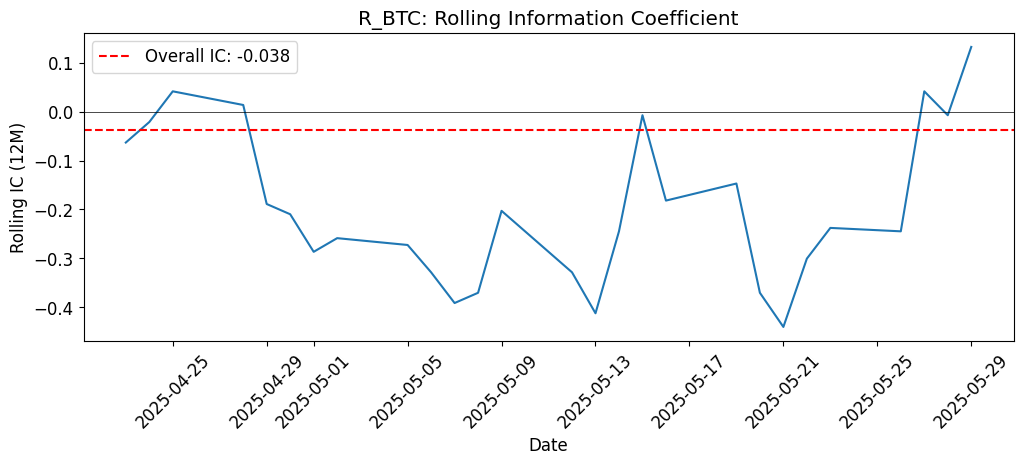


R_GOLD:
  Overall IC:       0.1315
  Mean Rolling IC:  0.2042
  Std Rolling IC:   0.1411
  IC Stability:     1.4467


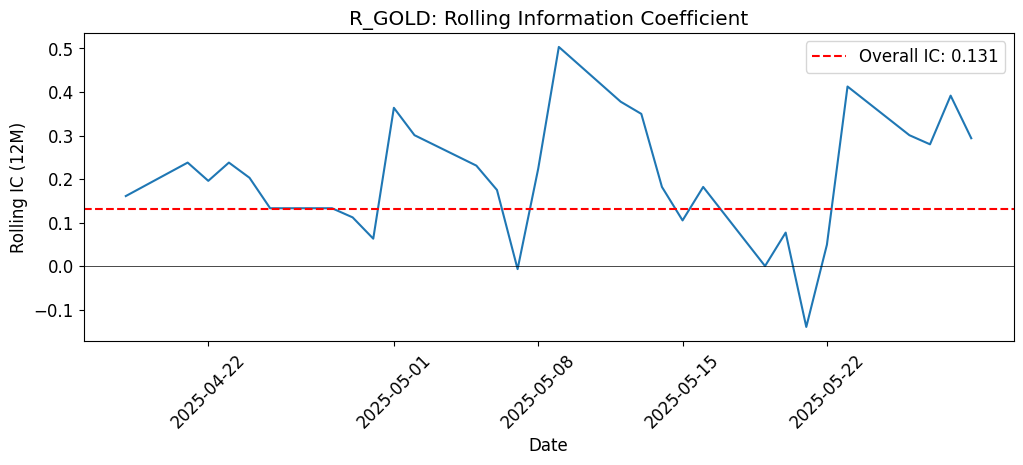


R_SPX:
  Overall IC:       0.0617
  Mean Rolling IC:  0.2284
  Std Rolling IC:   0.3337
  IC Stability:     0.6843


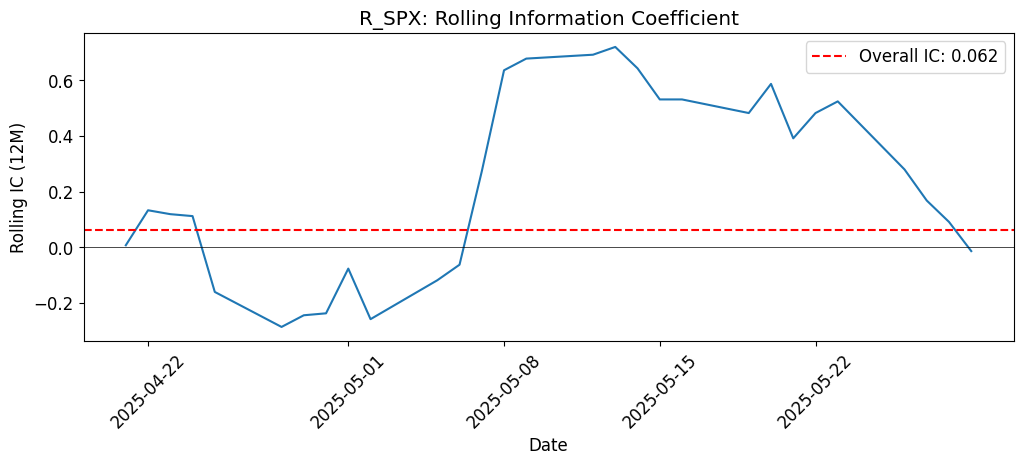


R_SPX_AUTO:
  Overall IC:       -0.1429
  Mean Rolling IC:  -0.2654
  Std Rolling IC:   0.2921
  IC Stability:     -0.9086


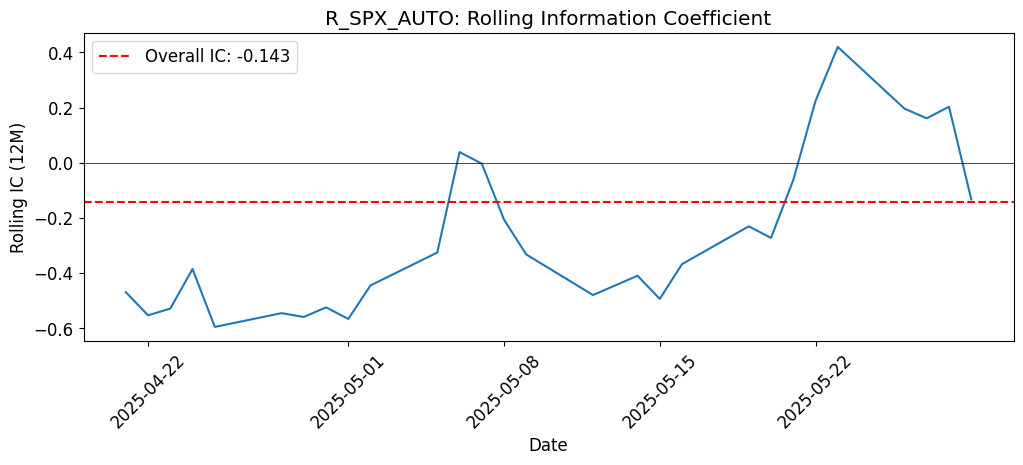


R_SPX_OILGAS:
  Overall IC:       0.1616
  Mean Rolling IC:  0.1167
  Std Rolling IC:   0.2087
  IC Stability:     0.5592


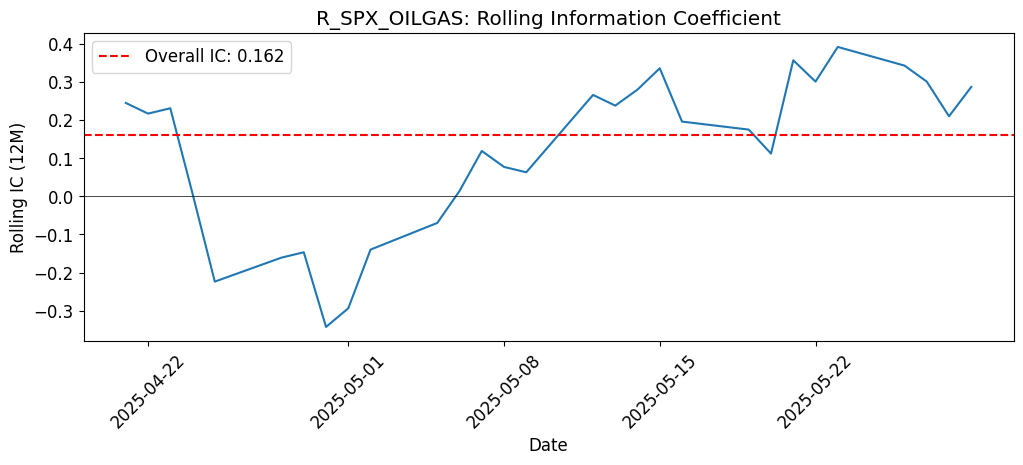


R_SPX_MACH:
  Overall IC:       -0.0500
  Mean Rolling IC:  -0.2785
  Std Rolling IC:   0.2143
  IC Stability:     -1.2996


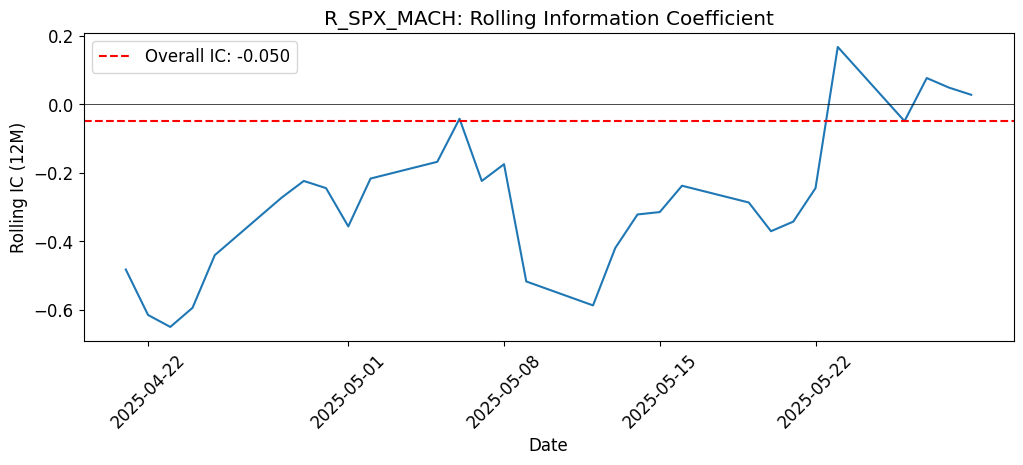


R_SPX_ELEC:
  Overall IC:       0.1563
  Mean Rolling IC:  -0.0000
  Std Rolling IC:   0.2588
  IC Stability:     -0.0000


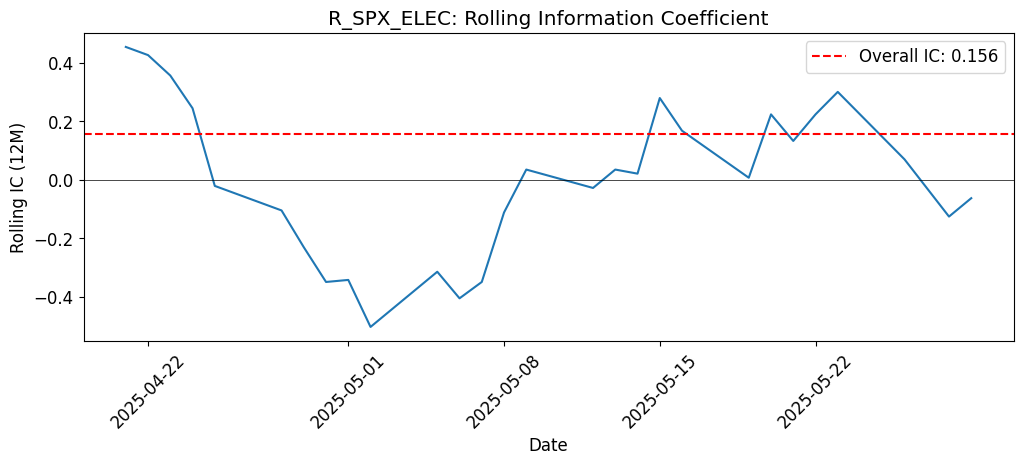


R_AAPL:
  Overall IC:       0.0241
  Mean Rolling IC:  -0.3377
  Std Rolling IC:   0.2000
  IC Stability:     -1.6891


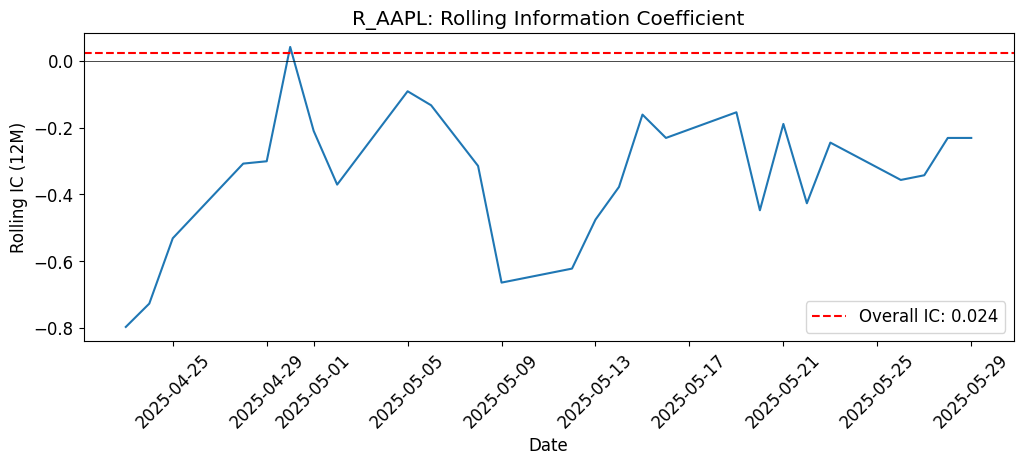

In [10]:
# Volatility Clustering Analysis
from modules.finance.evaluation.trading_metrics import (
    compute_volatility_clustering,
    compute_overfitting_diagnostics,
    compute_coefficient_stability
)

print("="*80)
print("VOLATILITY CLUSTERING ANALYSIS (ACF of Squared Residuals)")
print("="*80)

for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    residuals = preds_df['y_true'].values - preds_df['y_pred'].values
    
    clustering_metrics = compute_volatility_clustering(residuals, max_lags=20)
    
    print(f"\n{target.upper()}:")
    print(f"  ACF(1):  {clustering_metrics['acf_lag1']:.4f}")
    print(f"  ACF(5):  {clustering_metrics['acf_lag5']:.4f}")
    print(f"  ACF(10): {clustering_metrics['acf_lag10']:.4f}")
    print(f"  Ljung-Box p-value: {clustering_metrics['ljung_box_pvalue']:.4f}")
    if clustering_metrics['ljung_box_pvalue'] < 0.05:
        print(f"  ✓ Significant volatility clustering detected (p < 0.05)")
    else:
        print(f"  ✗ No significant volatility clustering (p >= 0.05)")
    
    # Plot ACF
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(clustering_metrics['acf_values'])), clustering_metrics['acf_values'])
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    plt.axhline(y=1.96/np.sqrt(len(residuals)), color='r', linestyle='--', label='95% CI')
    plt.axhline(y=-1.96/np.sqrt(len(residuals)), color='r', linestyle='--')
    plt.xlabel('Lag')
    plt.ylabel('ACF')
    plt.title(f'{target.upper()}: ACF of Squared Residuals')
    plt.legend()
    plt.savefig(OUTPUT_DIR / f'arx_baseline_{target}_volatility_clustering.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "="*80)
print("OVERFITTING DIAGNOSTICS (Information Coefficient)")
print("="*80)

for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    
    overfitting_metrics = compute_overfitting_diagnostics(
        y_true=preds_df['y_true'].values,
        y_pred=preds_df['y_pred'].values,
        dates=preds_df.index,
        window_size=12  # 12 months rolling window
    )
    
    print(f"\n{target.upper()}:")
    print(f"  Overall IC:       {overfitting_metrics['ic']:.4f}")
    print(f"  Mean Rolling IC:  {overfitting_metrics['ic_rolling_mean']:.4f}")
    print(f"  Std Rolling IC:   {overfitting_metrics['ic_rolling_std']:.4f}")
    print(f"  IC Stability:     {overfitting_metrics['ic_stability']:.4f}")
    
    # Plot rolling IC
    plt.figure(figsize=(12, 4))
    plt.plot(overfitting_metrics['ic_rolling_dates'], overfitting_metrics['ic_rolling_values'])
    plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    plt.axhline(y=overfitting_metrics['ic'], color='r', linestyle='--', label=f'Overall IC: {overfitting_metrics["ic"]:.3f}')
    plt.xlabel('Date')
    plt.ylabel('Rolling IC (12M)')
    plt.title(f'{target.upper()}: Rolling Information Coefficient')
    plt.legend()
    plt.xticks(rotation=45)
    plt.savefig(OUTPUT_DIR / f'arx_baseline_{target}_rolling_ic.png', dpi=150, bbox_inches='tight')
    plt.show()

## Coefficient Analysis with Bootstrap Confidence Intervals

Analyze model coefficients with bootstrap-based statistical significance testing at multiple levels (1%, 5%, 10%).

In [11]:
# Bootstrap analysis for each asset
bootstrap_results = {}

for target in TARGET_COLS:
    print(f"\nBootstrap analysis for {target}...")
    
    # Get data from stored results
    X_design = baseline_results[target]['X_supervised']
    y_design = baseline_results[target]['y_supervised']
    pipeline = baseline_results[target]['fitted_pipeline']
    feature_names = baseline_results[target]['feature_names']
    
    # Run bootstrap
    ci_df = bootstrap_coefficient_ci(
        X=X_design.values,
        y=y_design.values,
        pipeline=pipeline,
        feature_names=feature_names,
        n_iter=500,  # Reduced for speed
        alpha_levels=[0.01, 0.05, 0.10],
    )
    
    bootstrap_results[target] = ci_df
    
    # Display significant features (index is the feature name)
    sig_features = ci_df[ci_df['stars'] != '']
    print(f"  Features significant at α=0.10 or better:")
    if len(sig_features) > 0:
        for feat_name in sig_features.index:
            row = sig_features.loc[feat_name]
            print(f"    {feat_name}: {row['coef']:.6f} (p={row['pvalue']:.4f}) {row['stars']}")
    else:
        print("    No significant features")


Bootstrap analysis for r_btc...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_gold...
  Features significant at α=0.10 or better:
    y_lag1: 0.001897 (p=0.0440) **
    y_lag2: 0.002011 (p=0.0280) **
    ctl_dy10_lag1: 0.002281 (p=0.0640) *

Bootstrap analysis for r_spx...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_spx_auto...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_spx_oilgas...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_spx_mach...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_spx_elec...
  Features significant at α=0.10 or better:
    No significant features

Bootstrap analysis for r_aapl...
  Features significant at α=0.10 or better:
    No significant features


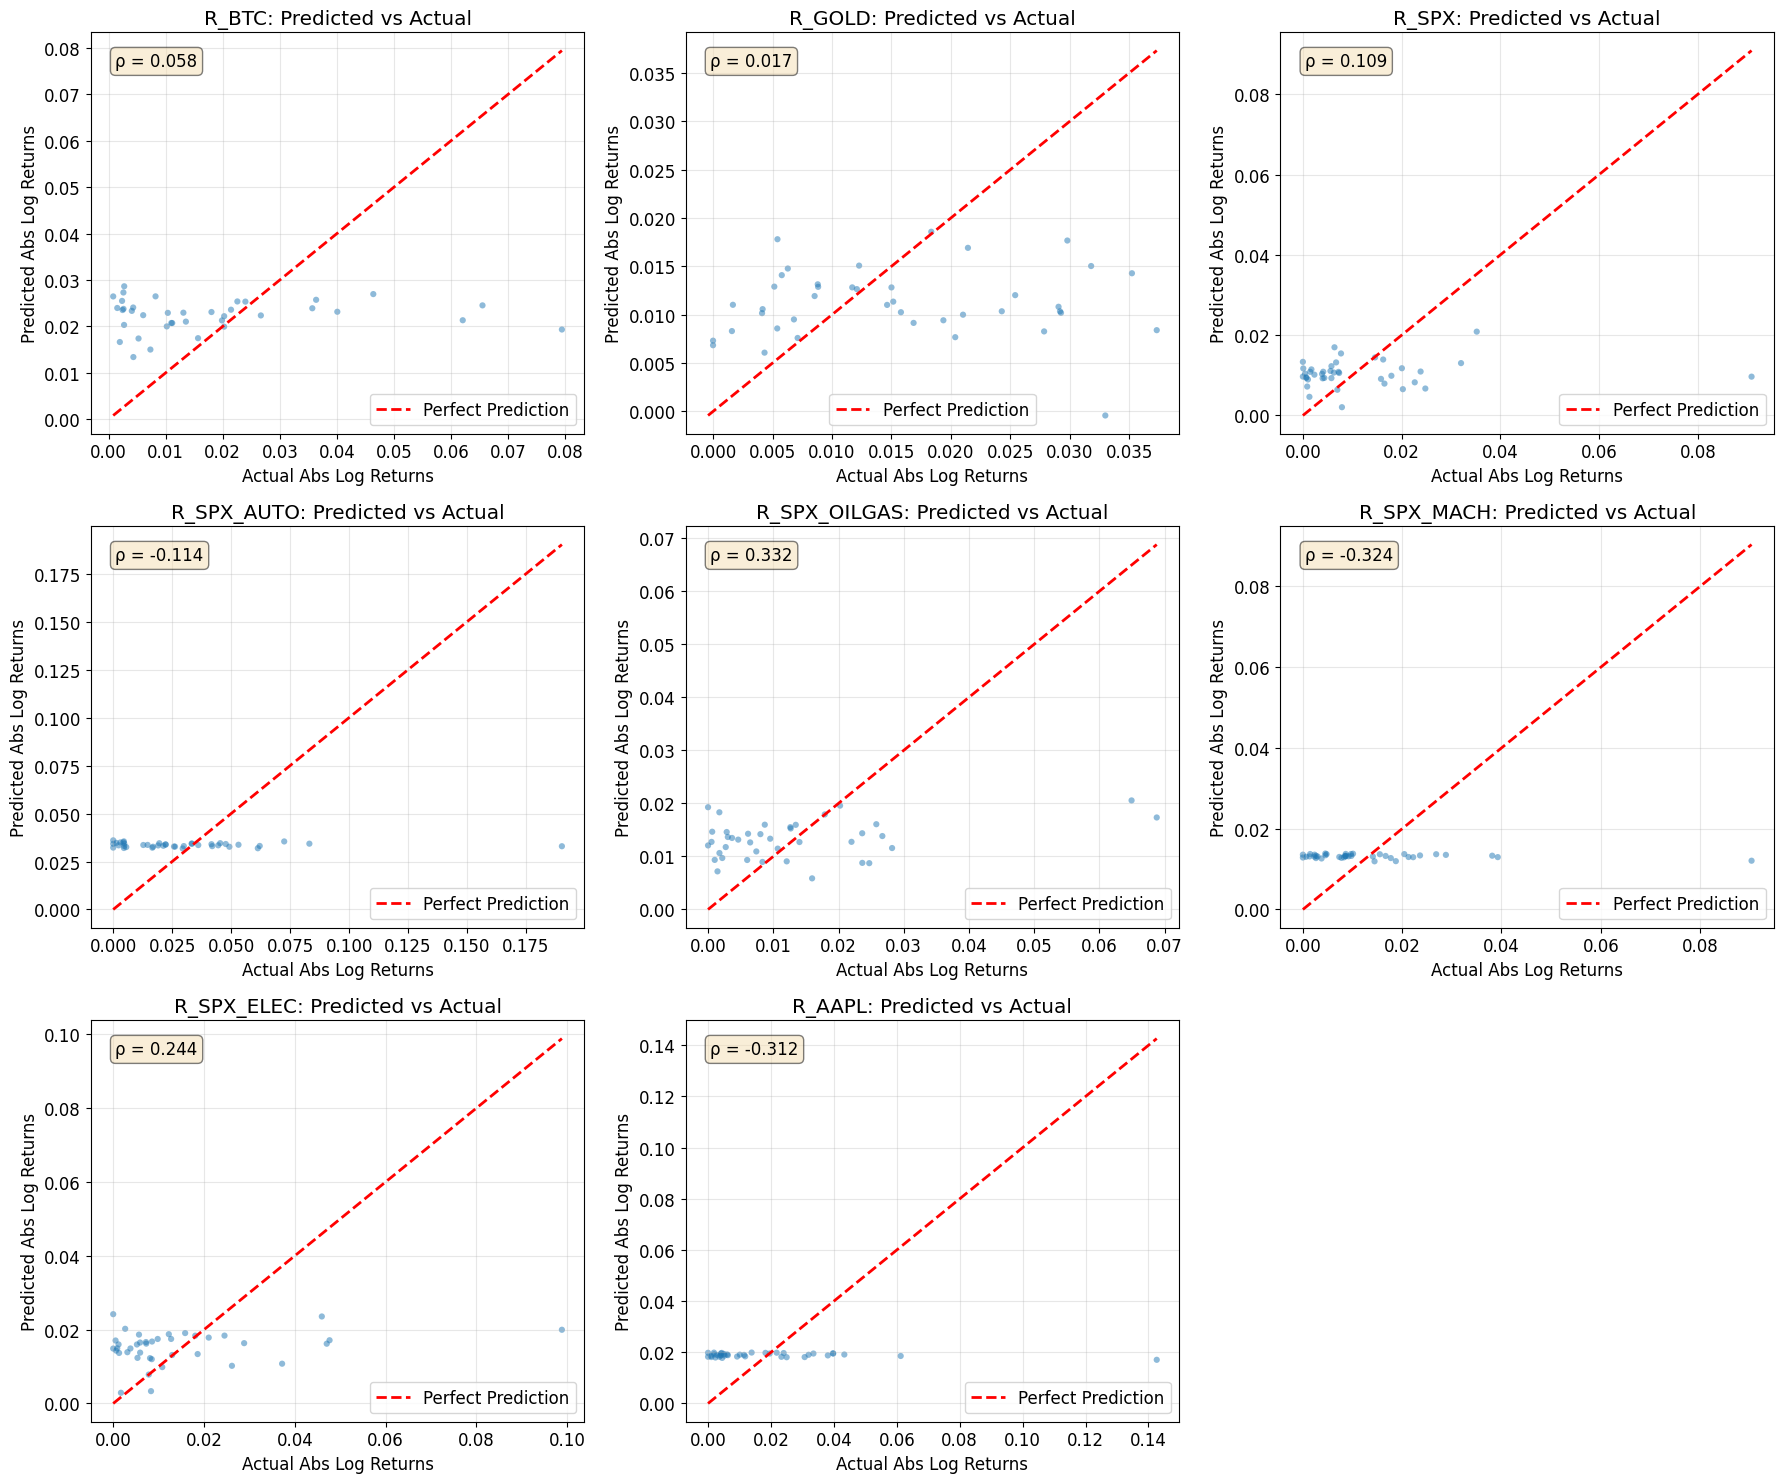


Correlation between predicted and actual:
  r_btc: 0.0577
  r_gold: 0.0165
  r_spx: 0.1092
  r_spx_auto: -0.1142
  r_spx_oilgas: 0.3318
  r_spx_mach: -0.3239
  r_spx_elec: 0.2436
  r_aapl: -0.3119


In [12]:
# Plot predicted vs actual absolute log returns
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    preds_df = oos_predictions[target]
    
    # Scatter plot
    ax.scatter(preds_df['y_true'], preds_df['y_pred'], alpha=0.5, s=20, edgecolors='none')
    
    # Perfect prediction line
    min_val = min(preds_df['y_true'].min(), preds_df['y_pred'].min())
    max_val = max(preds_df['y_true'].max(), preds_df['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel('Actual Abs Log Returns')
    ax.set_ylabel('Predicted Abs Log Returns')
    ax.set_title(f'{target.upper()}: Predicted vs Actual')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    ax.text(0.05, 0.95, f'ρ = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation between predicted and actual:")
for target in TARGET_COLS:
    preds_df = oos_predictions[target]
    corr = np.corrcoef(preds_df['y_true'], preds_df['y_pred'])[0, 1]
    print(f"  {target}: {corr:.4f}")

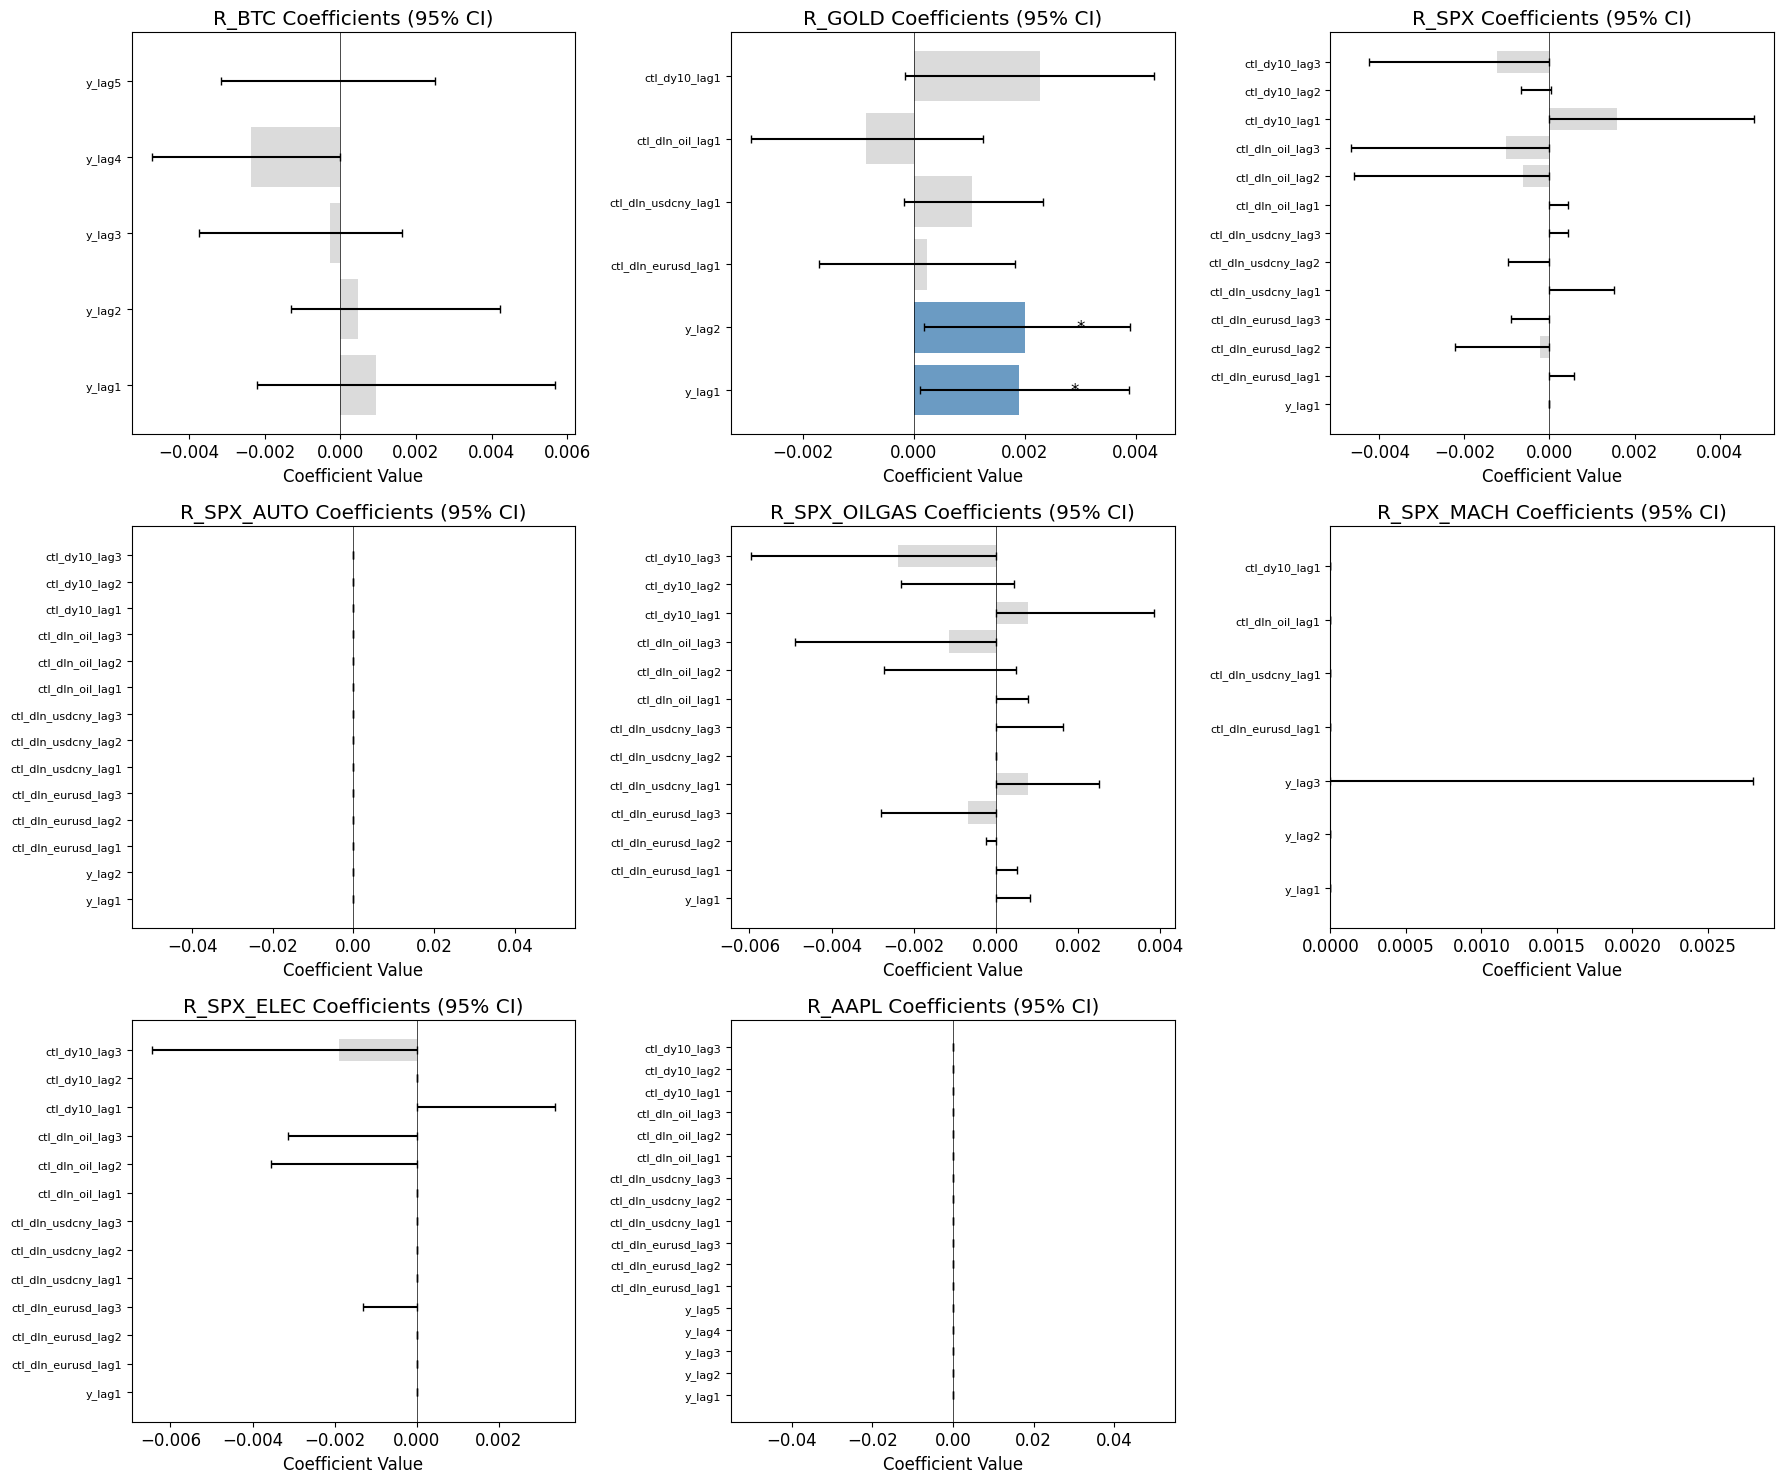

In [13]:
# Visualize coefficients with significance
n_cols = min(3, len(TARGET_COLS))
n_rows = (len(TARGET_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    ci_df = bootstrap_results[target]
    features = list(ci_df.index)
    means = ci_df['coef'].values
    
    # Get 95% CI bounds
    ci_lower = ci_df['ci_lower_95'].values if 'ci_lower_95' in ci_df.columns else means - ci_df['se'].values * 1.96
    ci_upper = ci_df['ci_upper_95'].values if 'ci_upper_95' in ci_df.columns else means + ci_df['se'].values * 1.96
    significant = ci_df['sig_95'].values if 'sig_95' in ci_df.columns else [False] * len(means)
    
    # Error bars
    errors = [np.abs(means - ci_lower), np.abs(ci_upper - means)]
    
    # Colors based on significance
    colors = ['steelblue' if sig else 'lightgray' for sig in significant]
    
    y_pos = np.arange(len(features))
    ax.barh(y_pos, means, xerr=errors, color=colors, capsize=3, alpha=0.8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(f'{target.upper()} Coefficients (95% CI)')
    
    # Add significance markers
    for i, (sig, mean) in enumerate(zip(significant, means)):
        if sig:
            offset = 0.001 if mean > 0 else -0.001
            ax.annotate('*', (mean + offset, i), fontsize=12, ha='center', va='center')

# Hide extra subplots if any
for idx in range(len(TARGET_COLS), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'arx_baseline_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Results

Save all baseline results to CSV files for later comparison with emotion-enhanced models.

In [14]:
# Save metrics summary
metrics_output = []
for target in TARGET_COLS:
    lags = baseline_results[target]['best_lags']
    cv = baseline_results[target]
    oos = oos_metrics[target]
    cum_ret = cumulative_returns[target]
    
    metrics_output.append({
        'asset': target,
        'model': 'ARX_baseline',
        'p': lags.ar_p,
        'q_controls': lags.q_controls,
        'cv_mae': cv['cv_mae'],
        'cv_rmse': cv['cv_rmse'],
        'oos_mae': oos['mae'],
        'oos_rmse': oos['rmse'],
        'oos_mape': oos['mape'],
        'oos_r2': oos['r2'],
        'cum_return_buy_hold': cum_ret['final_buy_hold'],
        'cum_return_strategy': cum_ret['final_strategy'],
    })

metrics_output_df = pd.DataFrame(metrics_output)
metrics_output_df.to_csv(OUTPUT_DIR / 'arx_baseline_metrics.csv', index=False)
print(f"Saved metrics to {OUTPUT_DIR / 'arx_baseline_metrics.csv'}")

# Save predictions
for target in TARGET_COLS:
    oos_predictions[target].to_csv(OUTPUT_DIR / f'arx_baseline_predictions_{target}.csv')
print(f"Saved predictions to {OUTPUT_DIR}")

# Save bootstrap results
bootstrap_output = []
for target in TARGET_COLS:
    ci_df = bootstrap_results[target]
    for feat_name in ci_df.index:
        row = ci_df.loc[feat_name]
        bootstrap_output.append({
            'asset': target,
            'feature': feat_name,
            'coef': row['coef'],
            'se': row.get('se', np.nan),
            'pvalue': row.get('pvalue', np.nan),
            'stars': row.get('stars', ''),
            'ci_lower_95': row.get('ci_lower_95', np.nan),
            'ci_upper_95': row.get('ci_upper_95', np.nan),
            'sig_95': row.get('sig_95', False),
        })

bootstrap_df = pd.DataFrame(bootstrap_output)
bootstrap_df.to_csv(OUTPUT_DIR / 'arx_baseline_bootstrap.csv', index=False)
print(f"Saved bootstrap results to {OUTPUT_DIR / 'arx_baseline_bootstrap.csv'}")

print("\n✅ All baseline ARX results saved successfully!")

Saved metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_baseline_metrics.csv
Saved predictions to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim
Saved bootstrap results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/arx_baseline_bootstrap.csv

✅ All baseline ARX results saved successfully!
